In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [166]:
df = pd.read_csv("../data/processed/AIS_Tableau_Final_Operational_Enhanced.csv")

df.head()

,shipname,vessel_type,operational_risk_category_pct,operational_risk_score_final,maintenance_risk_score_norm,predicted_high_traffic,weather_risk_score_norm
0,44,NaN,High,0.716970,0.987258,1,0.069307
1,33,NaN,High,0.615541,0.545202,1,0.173267
2,133,NaN,High,0.370905,0.676945,0,0.559406
3,32,NaN,High,NaN,0.648349,1,NaN
4,62,NaN,Low,0.173673,0.291782,0,0.287129


In [167]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   shipname                       158 non-null    int64  
 1   vessel_type                    0 non-null      float64
 2   operational_risk_category_pct  158 non-null    str    
 3   operational_risk_score_final   94 non-null     float64
 4   maintenance_risk_score_norm    158 non-null    float64
 5   predicted_high_traffic         158 non-null    int64  
 6   weather_risk_score_norm        94 non-null     float64
dtypes: float64(4), int64(2), str(1)
memory usage: 8.8 KB


In [168]:
df.describe()

,shipname,vessel_type,operational_risk_score_final,maintenance_risk_score_norm,predicted_high_traffic,weather_risk_score_norm
count,158.000000,0.0,94.000000,158.000000,158.000000,94.000000
mean,79.493671,NaN,0.206988,0.503511,0.018987,0.148462
std,45.765777,NaN,0.125537,0.282419,0.136914,0.238884
min,0.000000,NaN,0.003614,0.000000,0.000000,0.000000
25%,40.250000,NaN,0.128580,0.294516,0.000000,0.000000
50%,79.500000,NaN,0.195581,0.540654,0.000000,0.042079
75%,118.750000,NaN,0.269814,0.719857,0.000000,0.193069
max,158.000000,NaN,0.716970,1.000000,1.000000,1.000000


In [169]:
df.rename(columns={"shipname": "vessel_id"}, inplace=True)

In [170]:
df["vessel_type"].isnull().sum()

np.int64(158)

In [171]:
df.drop(columns=["vessel_type"], inplace=True)

In [172]:
df = df.dropna()

In [173]:
df.info()

<class 'pandas.DataFrame'>
Index: 94 entries, 0 to 153
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   vessel_id                      94 non-null     int64  
 1   operational_risk_category_pct  94 non-null     str    
 2   operational_risk_score_final   94 non-null     float64
 3   maintenance_risk_score_norm    94 non-null     float64
 4   predicted_high_traffic         94 non-null     int64  
 5   weather_risk_score_norm        94 non-null     float64
dtypes: float64(3), int64(2), str(1)
memory usage: 5.1 KB


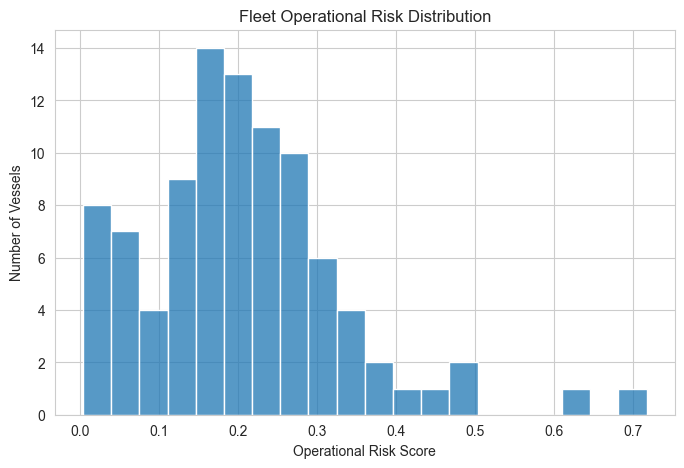

In [174]:
plt.figure(figsize=(8,5))

sns.histplot(df["operational_risk_score_final"], bins=20)

plt.title("Fleet Operational Risk Distribution")
plt.xlabel("Operational Risk Score")
plt.ylabel("Number of Vessels")

plt.show()

In [175]:
high_risk = df.sort_values(
    "operational_risk_score_final",
    ascending=False
)

high_risk.head(10)

,vessel_id,operational_risk_category_pct,operational_risk_score_final,maintenance_risk_score_norm,predicted_high_traffic,weather_risk_score_norm
0,44,High,0.716970,0.987258,1,0.069307
1,33,High,0.615541,0.545202,1,0.173267
87,158,High,0.494039,0.646798,0,1.000000
119,145,High,0.473973,0.579910,0,1.000000
19,82,High,0.443748,0.543515,0,0.935644
7,36,High,0.413360,0.442223,0,0.935644
26,2,High,0.372007,0.626162,0,0.613861
2,133,High,0.370905,0.676945,0,0.559406
17,34,High,0.347422,0.935302,0,0.222772
69,103,High,0.341566,0.138554,0,1.000000


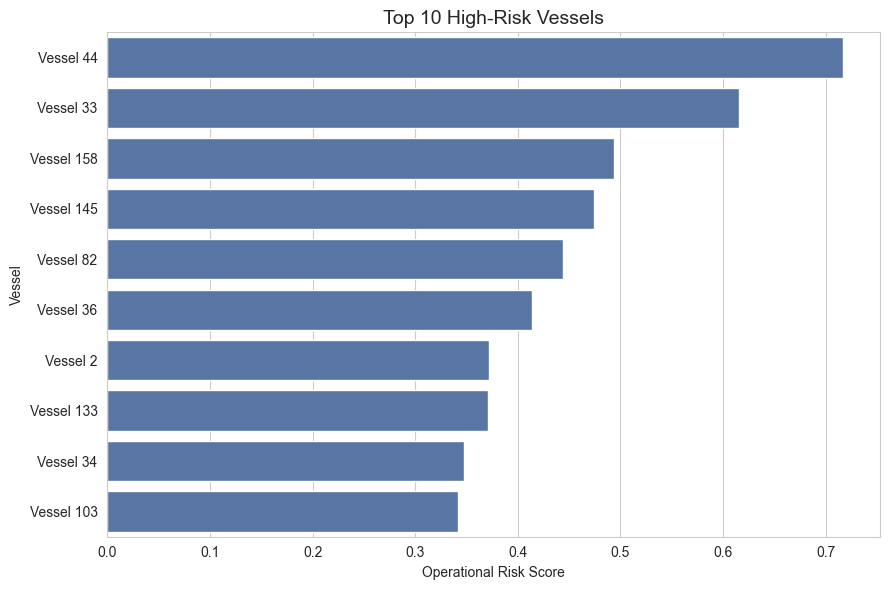

In [176]:
#Top 10 High-Risk Vessels

# Make a copy of top 10 vessels
top10 = high_risk.head(10).copy()

# Create readable labels
top10["vessel_label"] = "Vessel " + top10["vessel_id"].astype(str)

# Create the figure and axes explicitly
fig, ax = plt.subplots(figsize=(9,6))

# Plot the bar chart on this axes
sns.barplot(
    data=top10,
    x="operational_risk_score_final",
    y="vessel_label",
    color="#4C72B0",
    ax=ax
)

# Titles and labels
ax.set_title("Top 10 High-Risk Vessels", fontsize=14)
ax.set_xlabel("Operational Risk Score")
ax.set_ylabel("Vessel")

# Layout fix
plt.tight_layout()

# Save the figure **before showing**
fig.savefig("../docs/screens/phase5/top10_high_risk_vessels.png", dpi=300)

# Display the figure
plt.show()

In [177]:
# Filter vessels in high predicted traffic
traffic_anomalies = df[df["predicted_high_traffic"] == 1]

# How many vessels?
print("High traffic vessels:", len(traffic_anomalies))

High traffic vessels: 2


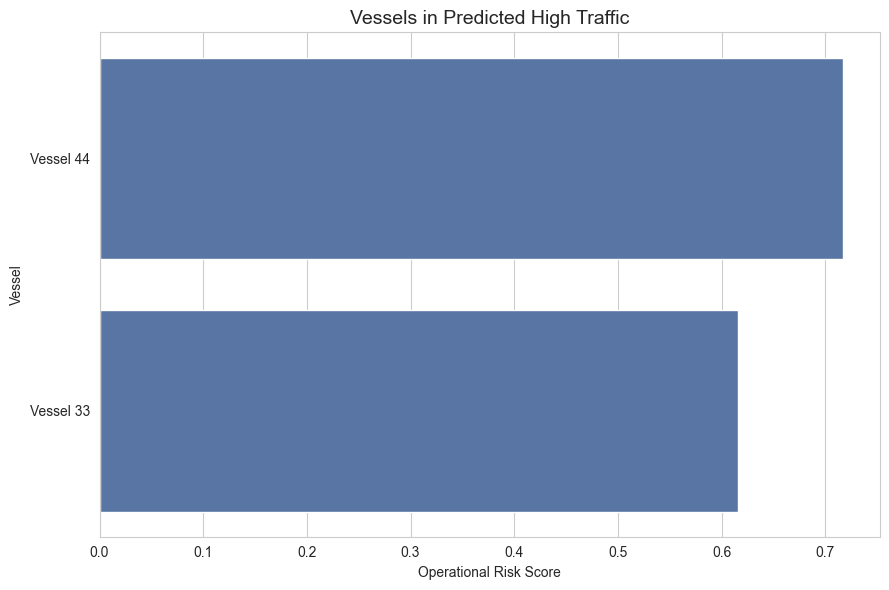

In [178]:
# Create readable labels
traffic_anomalies["vessel_label"] = "Vessel " + traffic_anomalies["vessel_id"].astype(str)

# Figure
fig, ax = plt.subplots(figsize=(9,6))

# Barplot
sns.barplot(
    data=traffic_anomalies,
    x="operational_risk_score_final",
    y="vessel_label",
    color="#4C72B0",
    ax=ax
)

# Titles and labels
ax.set_title("Vessels in Predicted High Traffic", fontsize=14)
ax.set_xlabel("Operational Risk Score")
ax.set_ylabel("Vessel")

plt.tight_layout()
fig.savefig("../docs/screens/phase5/high_traffic_vessels.png", dpi=300)
plt.show()

combined_risk_alert
Normal      67
Warning     25
Critical     2
Name: count, dtype: int64


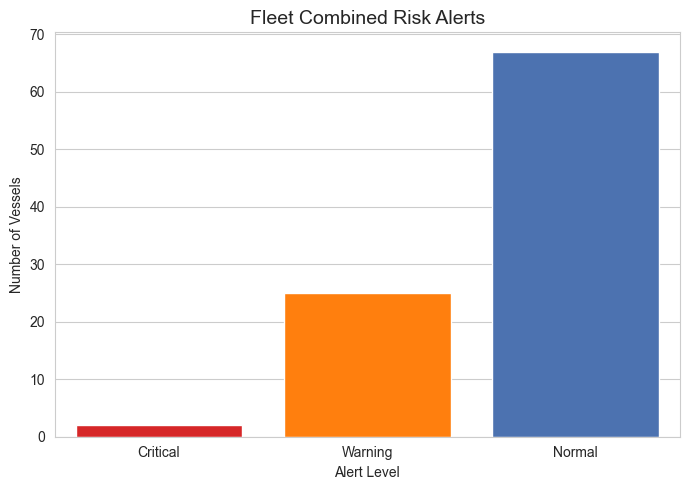

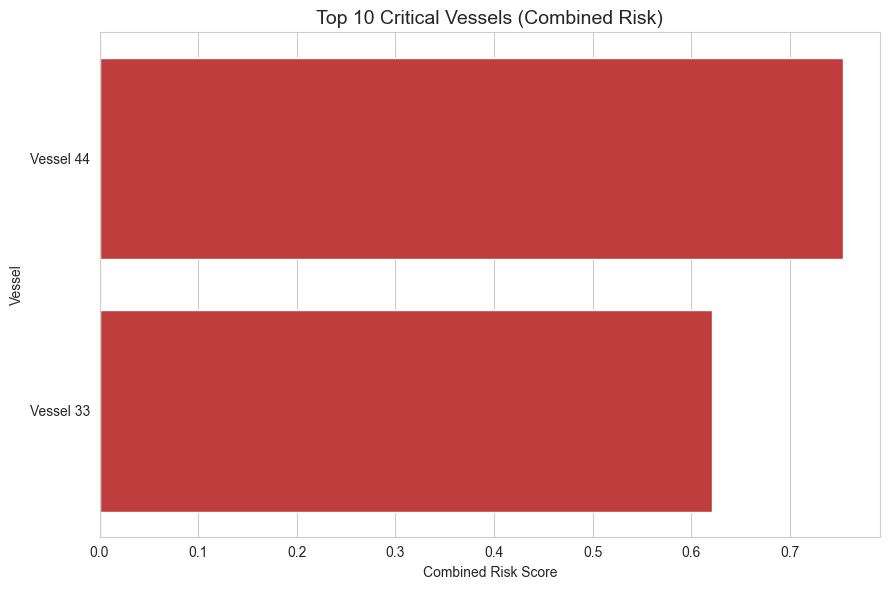

✅ Step 9 complete — Combined risk alerts calculated, charts saved, dataset exported.


In [192]:
# ================================
# Combined Risk Alert System (Future-Proof)
# ================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 
# Required columns: vessel_id, operational_risk_score_final, maintenance_risk_score_norm,
# predicted_high_traffic, weather_risk_score_norm

# 1️⃣ Create readable vessel labels
df = df.copy()  # prevent SettingWithCopyWarning
df["vessel_label"] = "Vessel " + df["vessel_id"].astype(str)

# 2️⃣ Compute combined risk score with weighted factors
# Weights: traffic=0.3, maintenance=0.3, weather=0.2, operational=0.2
if "combined_risk_score" not in df.columns:
    df["combined_risk_score"] = (
    0.3 * df["predicted_high_traffic"] +
    0.3 * df["maintenance_risk_score_norm"] +
    0.2 * df["weather_risk_score_norm"] +
    0.2 * df["operational_risk_score_final"]
)
 
#   Compute combined risk alert if missing
if "combined_risk_alert" not in df.columns:
    def combined_alert(score):
        if score > 0.6:
            return "Critical"
        elif score > 0.3:
            return "Warning"
        else:
            return "Normal"
    df["combined_risk_alert"] = df["combined_risk_score"].apply(combined_alert)
    
# 3️⃣ Assign human-readable risk alert levels
def combined_alert(score):
    if score > 0.6:
        return "Critical"
    elif score > 0.3:
        return "Warning"
    else:
        return "Normal"

df["combined_risk_alert"] = df["combined_risk_score"].apply(combined_alert)

# 4️⃣ Inspect alert counts
print(df["combined_risk_alert"].value_counts())

# ================================
# 5️⃣ Visualization — Fleet Alert Levels (no warnings)
# ================================
fig, ax = plt.subplots(figsize=(7,5))

# Create the countplot without palette
sns.countplot(
    data=df,
    x="combined_risk_alert",
    order=["Critical","Warning","Normal"],
    ax=ax
)

# Apply colors manually to avoid FutureWarning
color_map = {"Critical": "#d62728", "Warning": "#ff7f0e", "Normal": "#4C72B0"}
for bar, alert_label in zip(ax.patches, ["Critical","Warning","Normal"]):
    bar.set_facecolor(color_map[alert_label])

ax.set_title("Fleet Combined Risk Alerts", fontsize=14)
ax.set_xlabel("Alert Level")
ax.set_ylabel("Number of Vessels")

plt.tight_layout()
fig.savefig("../docs/screens/phase5/combined_risk_alerts.png", dpi=300)
plt.show()

# ================================
# 6️⃣ Visualization — Top 10 Critical Vessels
# ================================
top_critical = df[df["combined_risk_alert"]=="Critical"].sort_values(
    "combined_risk_score", ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(9,6))

sns.barplot(
    data=top_critical,
    x="combined_risk_score",
    y="vessel_label",
    color="#d62728",  # Red for Critical
    ax=ax
)

ax.set_title("Top 10 Critical Vessels (Combined Risk)", fontsize=14)
ax.set_xlabel("Combined Risk Score")
ax.set_ylabel("Vessel")

plt.tight_layout()
fig.savefig("../docs/screens/phase5/top10_critical_vessels.png", dpi=300)
plt.show()

# ================================
# 7️⃣ Export dataset with combined risk
# ================================
df.to_csv("../data/processed/phase5_combined_risk_alerts.csv", index=False)

print("✅ Step 9 complete — Combined risk alerts calculated, charts saved, dataset exported.")

✅ Total anomalies detected: 5


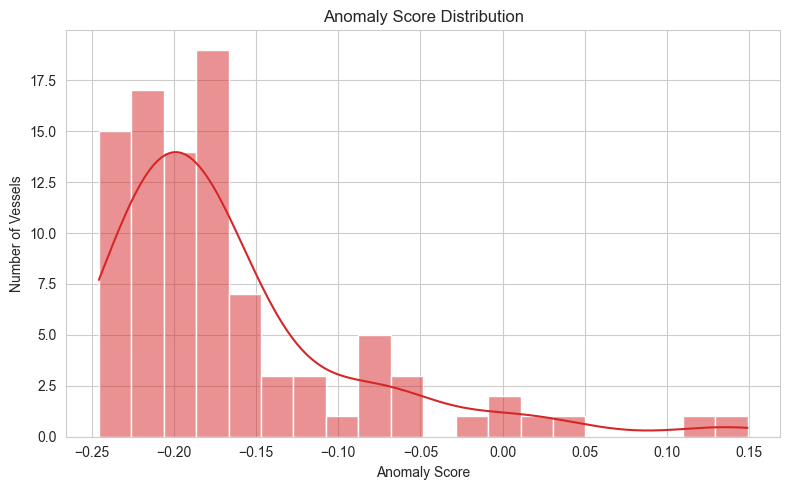

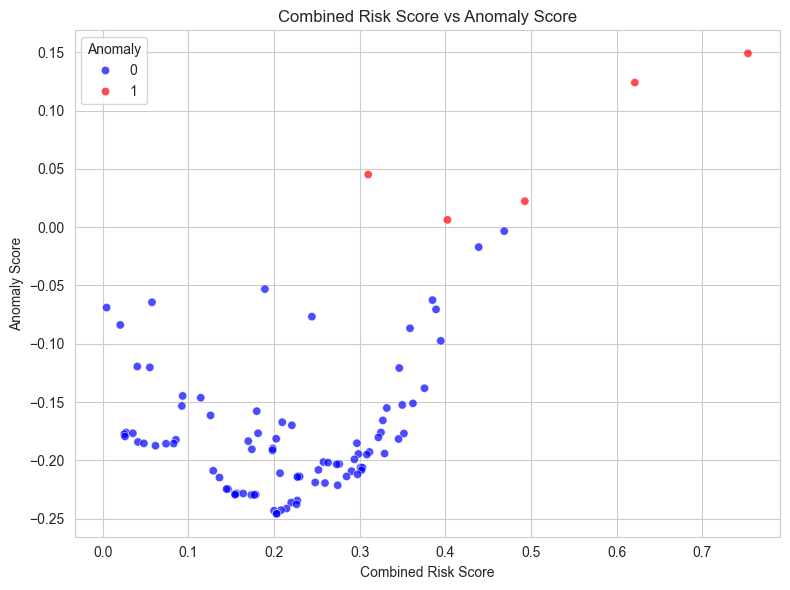

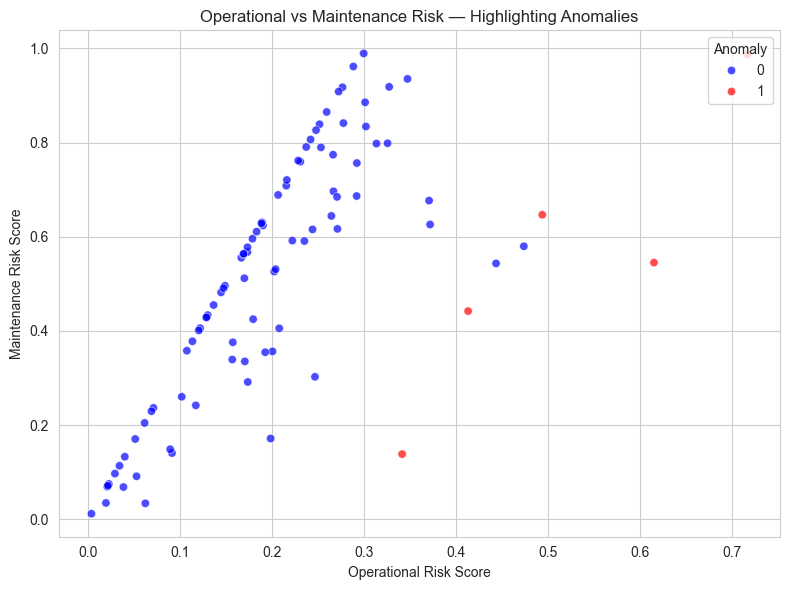

✅ Fleet Risk Intelligence dataset exported.


In [197]:
# ================================
# AI Anomaly Detection & Fleet Risk Intelligence
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

sns.set_style("whitegrid")

# -------------------------------
# 1️⃣ Load dataset
# -------------------------------
df = pd.read_csv("../data/processed/AIS_Tableau_Final_Operational_Enhanced.csv")

# -------------------------------
# 2️⃣ Clean dataset
# -------------------------------
# Drop vessel_type (all NaN) and rows missing key scores
df = df.drop(columns=["vessel_type"], errors="ignore")
df = df.dropna(subset=[
    "operational_risk_score_final",
    "maintenance_risk_score_norm",
    "weather_risk_score_norm"
]).copy()

# Add readable vessel labels
df["vessel_label"] = "Vessel " + df["shipname"].astype(str)

# -------------------------------
# 3️⃣ Ensure combined risk exists
# -------------------------------
if "combined_risk_score" not in df.columns:
    df["combined_risk_score"] = (
        0.3 * df["predicted_high_traffic"] +
        0.3 * df["maintenance_risk_score_norm"] +
        0.2 * df["weather_risk_score_norm"] +
        0.2 * df["operational_risk_score_final"]
    )

if "combined_risk_alert" not in df.columns:
    def combined_alert(score):
        if score > 0.6:
            return "Critical"
        elif score > 0.3:
            return "Warning"
        else:
            return "Normal"
    df["combined_risk_alert"] = df["combined_risk_score"].apply(combined_alert)

# -------------------------------
# 4️⃣ Prepare numeric features for anomaly detection
# -------------------------------
features = [
    "operational_risk_score_final",
    "maintenance_risk_score_norm",
    "weather_risk_score_norm",
    "predicted_high_traffic"
]

X = df[features].fillna(0)

# -------------------------------
# 5️⃣ Isolation Forest — detect anomalies
# -------------------------------
iso_model = IsolationForest(
    n_estimators=150,
    contamination=0.05,  # ~5% anomalies
    max_samples="auto",
    random_state=99
)
iso_model.fit(X)

# Predict anomalies (1 = normal, -1 = anomaly)
# Corrected: wrap in np.where to avoid AttributeError
df["anomaly_flag"] = np.where(iso_model.predict(X) == -1, 1, 0)

# Compute anomaly scores (higher = more anomalous)
df["anomaly_score"] = -iso_model.decision_function(X)

# -------------------------------
# 6️⃣ Rank vessels by anomaly severity
# -------------------------------
df = df.sort_values("anomaly_score", ascending=False)
anomalies = df[df["anomaly_flag"] == 1]
print(f"✅ Total anomalies detected: {len(anomalies)}")
anomalies[[
    "vessel_label",
    "operational_risk_score_final",
    "maintenance_risk_score_norm",
    "weather_risk_score_norm",
    "predicted_high_traffic",
    "anomaly_score"
]].head(10)

# -------------------------------
# 7️⃣ Visualization — Anomaly Score Distribution
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df["anomaly_score"], bins=20, kde=True, color="#d62728")
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Vessels")
plt.tight_layout()
plt.savefig("../docs/screens/phase5/anomaly_score_distribution.png", dpi=300)
plt.show()

# -------------------------------
# 8️⃣ Visualization — Risk vs Anomaly
# -------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="combined_risk_score",
    y="anomaly_score",
    hue="anomaly_flag",
    palette={0: "blue", 1: "red"},
    alpha=0.7
)
plt.title("Combined Risk Score vs Anomaly Score")
plt.xlabel("Combined Risk Score")
plt.ylabel("Anomaly Score")
plt.legend(title="Anomaly", loc="upper left")
plt.tight_layout()
plt.savefig("../docs/screens/phase5/risk_vs_anomaly.png", dpi=300)
plt.show()

# -------------------------------
# 9️⃣ Visualization — Anomalies in Operational vs Maintenance Risk
# -------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="operational_risk_score_final",
    y="maintenance_risk_score_norm",
    hue="anomaly_flag",
    palette={0: "blue", 1: "red"},
    alpha=0.7
)
plt.title("Operational vs Maintenance Risk — Highlighting Anomalies")
plt.xlabel("Operational Risk Score")
plt.ylabel("Maintenance Risk Score")
plt.legend(title="Anomaly", loc="upper right")
plt.tight_layout()
plt.savefig("../docs/screens/phase5/op_vs_maint_anomalies.png", dpi=300)
plt.show()

# -------------------------------
# 10️⃣ Fleet Risk Intelligence Dataset
# -------------------------------
final_cols = [
    "shipname", "combined_risk_score", "combined_risk_alert",
    "anomaly_flag", "anomaly_score",
    "operational_risk_score_final",
    "maintenance_risk_score_norm",
    "weather_risk_score_norm",
    "predicted_high_traffic"
]

fleet_risk_df = df[final_cols].copy()
fleet_risk_df.rename(columns={"shipname": "vessel_id"}, inplace=True)

# -------------------------------
# 11️⃣ Export final dataset
# -------------------------------
fleet_risk_df.to_csv("../data/processed/AIS_Phase5_Final_Risk_Intelligence.csv", index=False)
print("✅ Fleet Risk Intelligence dataset exported.")

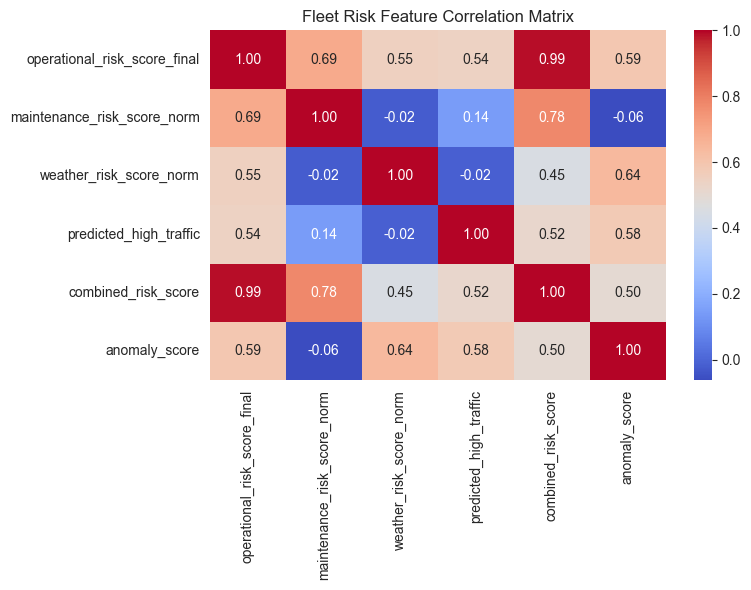

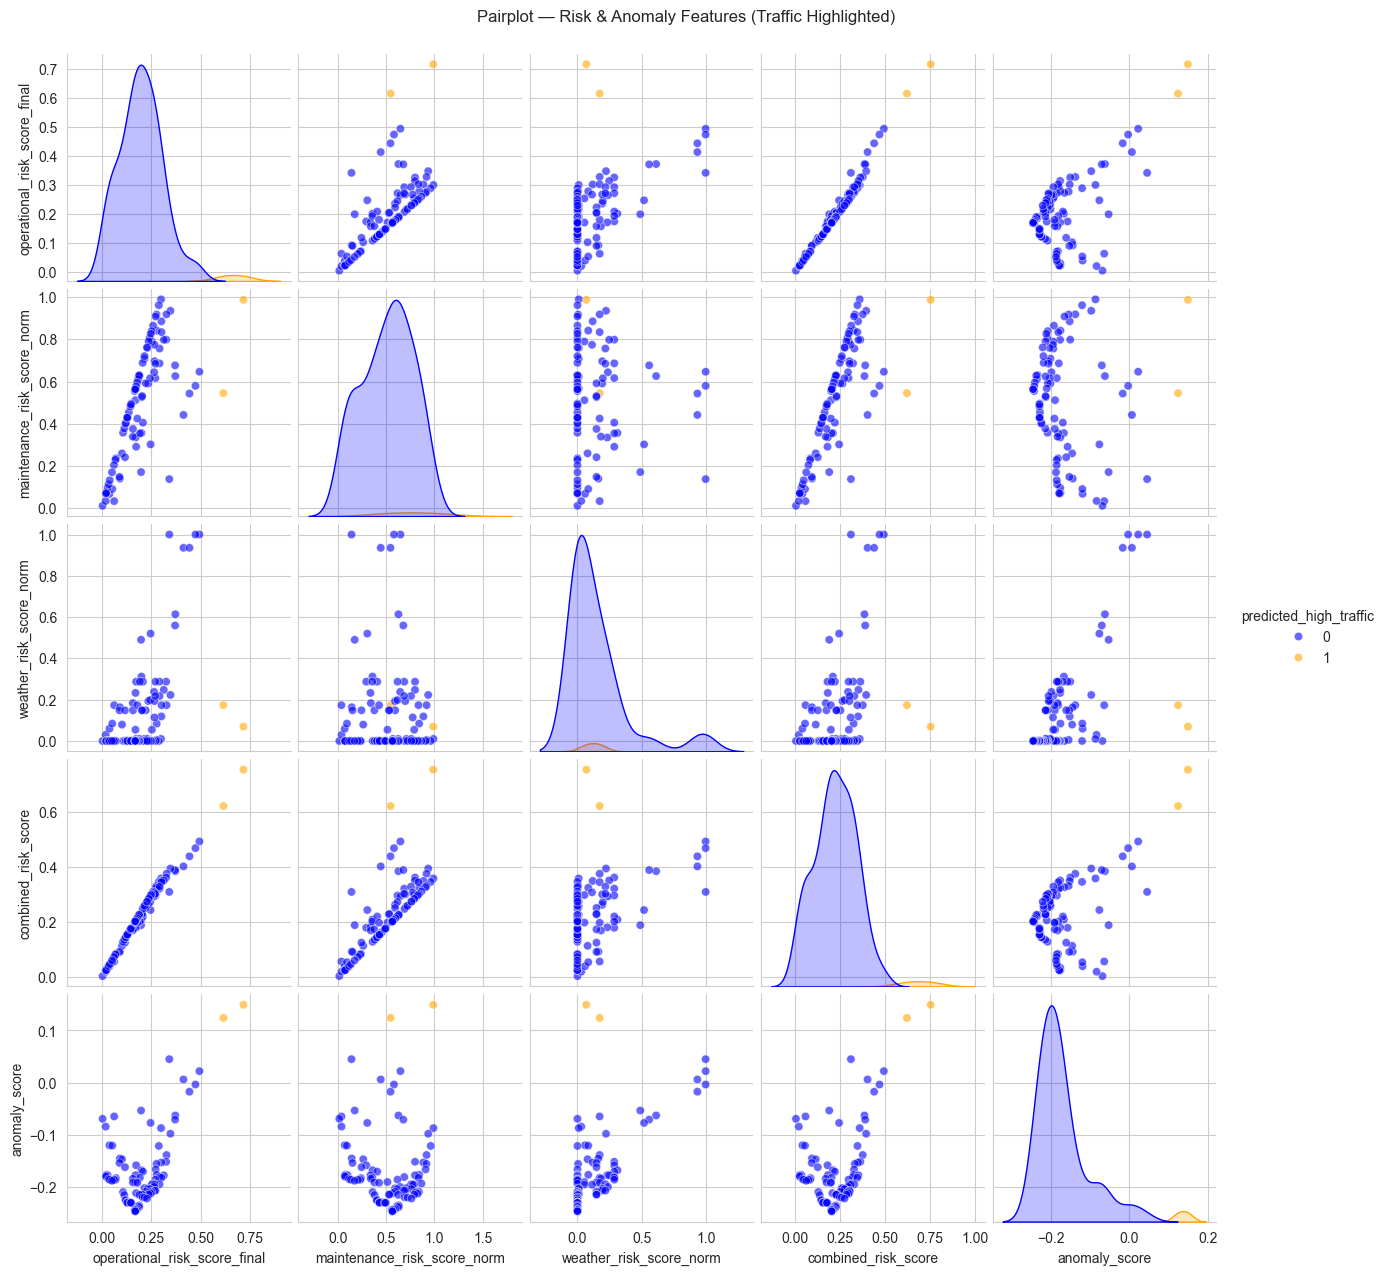

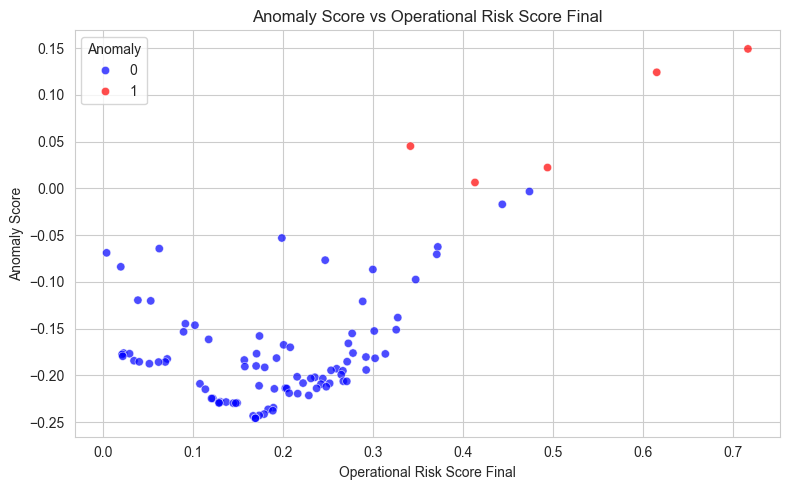

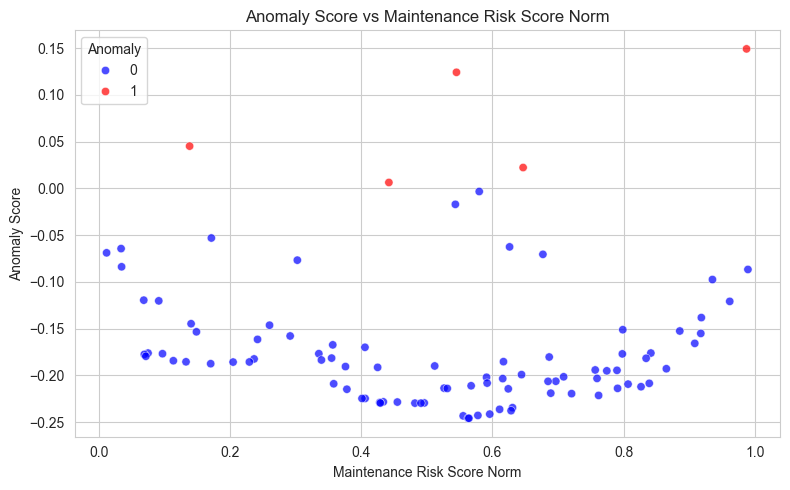

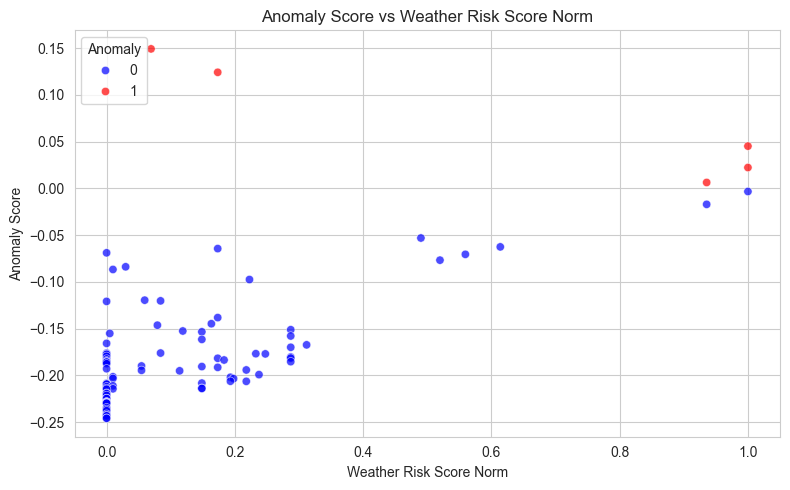

In [198]:
# ================================
# Risk Pattern Analysis
# ================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# -------------------------------
# 1️⃣ Load the Fleet Risk Intelligence dataset
# -------------------------------
df = pd.read_csv("../data/processed/AIS_Phase5_Final_Risk_Intelligence.csv")

# -------------------------------
# 2️⃣ Select numeric features for correlation
# -------------------------------
corr_features = [
    "operational_risk_score_final",
    "maintenance_risk_score_norm",
    "weather_risk_score_norm",
    "predicted_high_traffic",
    "combined_risk_score",
    "anomaly_score"
]

# -------------------------------
# 3️⃣ Compute correlation matrix
# -------------------------------
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Fleet Risk Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../docs/screens/phase5/correlation_matrix.png", dpi=300)
plt.show()

# -------------------------------
# 4️⃣ Pairplot for visual relationship exploration
# -------------------------------
pairplot_vars = [
    "operational_risk_score_final",
    "maintenance_risk_score_norm",
    "weather_risk_score_norm",
    "combined_risk_score",
    "anomaly_score"
]

sns.pairplot(
    df[pairplot_vars + ["predicted_high_traffic"]],
    hue="predicted_high_traffic",
    palette={0: "blue", 1: "orange"},
    diag_kind="kde",
    plot_kws={"alpha": 0.6}
)
plt.suptitle("Pairplot — Risk & Anomaly Features (Traffic Highlighted)", y=1.02)
plt.savefig("../docs/screens/phase5/risk_pairplot.png", dpi=300)
plt.show()

# -------------------------------
# 5️⃣ Scatter Analysis: anomaly vs each risk type
# -------------------------------
risk_types = [
    "operational_risk_score_final",
    "maintenance_risk_score_norm",
    "weather_risk_score_norm"
]

for risk in risk_types:
    plt.figure(figsize=(8,5))
    sns.scatterplot(
        data=df,
        x=risk,
        y="anomaly_score",
        hue="anomaly_flag",
        palette={0:"blue", 1:"red"},
        alpha=0.7
    )
    plt.title(f"Anomaly Score vs {risk.replace('_',' ').title()}")
    plt.xlabel(risk.replace('_',' ').title())
    plt.ylabel("Anomaly Score")
    plt.legend(title="Anomaly", loc="upper left")
    plt.tight_layout()
    plt.savefig(f"../docs/screens/phase5/anomaly_vs_{risk}.png", dpi=300)
    plt.show()

In [200]:
# ================================
#  Fleet Risk Intelligence Dataset 
# ================================

import pandas as pd

# -------------------------------
# 1️⃣ Load the latest Phase 5 dataset with combined risk and anomaly info
# -------------------------------
df = pd.read_csv("../data/processed/AIS_Phase5_Final_Risk_Intelligence.csv")

# -------------------------------
# 2️⃣ Recreate any missing runtime columns
# -------------------------------
if "vessel_label" not in df.columns:
    df["vessel_label"] = "Vessel " + df["vessel_id"].astype(str)

if "anomaly_score" not in df.columns:
    from sklearn.ensemble import IsolationForest

    # Prepare features for anomaly detection
    features = [
        "operational_risk_score_final",
        "maintenance_risk_score_norm",
        "weather_risk_score_norm",
        "predicted_high_traffic"
    ]
    X = df[features].fillna(0)

    # Fit Isolation Forest
    iso_model = IsolationForest(n_estimators=150, contamination=0.05, random_state=99)
    iso_model.fit(X)

    # Compute anomaly flags and scores
    df["anomaly_flag"] = iso_model.predict(X)
    df["anomaly_flag"] = df["anomaly_flag"].map({1: 0, -1: 1})
    df["anomaly_score"] = -iso_model.decision_function(X)  # higher = more anomalous

# -------------------------------
# 3️⃣ Select the relevant columns for the final intelligence dataset
# -------------------------------
final_columns = [
    "vessel_id",
    "vessel_label",
    "combined_risk_score",
    "combined_risk_alert",
    "anomaly_flag",
    "anomaly_score",
    "operational_risk_score_final",
    "maintenance_risk_score_norm",
    "weather_risk_score_norm",
    "predicted_high_traffic"
]

fleet_intelligence_df = df[final_columns].copy()

# -------------------------------
# 4️⃣ Sort by combined risk and anomaly for priority monitoring
# -------------------------------
fleet_intelligence_df = fleet_intelligence_df.sort_values(
    by=["combined_risk_score", "anomaly_score"],
    ascending=[False, False]
)

# -------------------------------
# 5️⃣ Export the final Fleet Risk Intelligence dataset
# -------------------------------
output_path = "../data/processed/AIS_Phase5_Final_Risk_Intelligence.csv"
fleet_intelligence_df.to_csv(output_path, index=False)

print(f"✅ Fleet Risk Intelligence dataset ready and saved: {output_path}")

# -------------------------------
# 6️⃣ Optional: Inspect top 10 highest-risk vessels
# -------------------------------
fleet_intelligence_df.head(10)

✅ Fleet Risk Intelligence dataset ready and saved: ../data/processed/AIS_Phase5_Final_Risk_Intelligence.csv


,vessel_id,vessel_label,combined_risk_score,combined_risk_alert,anomaly_flag,anomaly_score,operational_risk_score_final,maintenance_risk_score_norm,weather_risk_score_norm,predicted_high_traffic
0,44,Vessel 44,0.753433,Critical,1,0.149108,0.716970,0.987258,0.069307,1
1,33,Vessel 33,0.621322,Critical,1,0.124068,0.615541,0.545202,0.173267,1
3,158,Vessel 158,0.492847,Warning,1,0.022245,0.494039,0.646798,1.000000,0
5,145,Vessel 145,0.468768,Warning,0,-0.003381,0.473973,0.579910,1.000000,0
6,82,Vessel 82,0.438933,Warning,0,-0.017105,0.443748,0.543515,0.935644,0
4,36,Vessel 36,0.402468,Warning,1,0.006278,0.413360,0.442223,0.935644,0
15,34,Vessel 34,0.394629,Warning,0,-0.097498,0.347422,0.935302,0.222772,0
11,133,Vessel 133,0.389146,Warning,0,-0.070555,0.370905,0.676945,0.559406,0
8,2,Vessel 2,0.385022,Warning,0,-0.062581,0.372007,0.626162,0.613861,0
19,9,Vessel 9,0.375667,Warning,0,-0.138191,0.327495,0.918383,0.173267,0


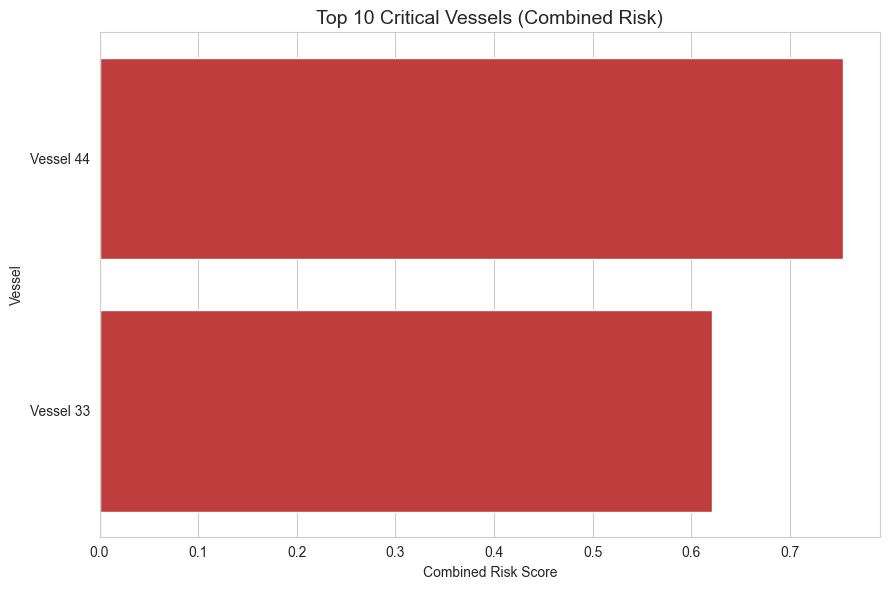

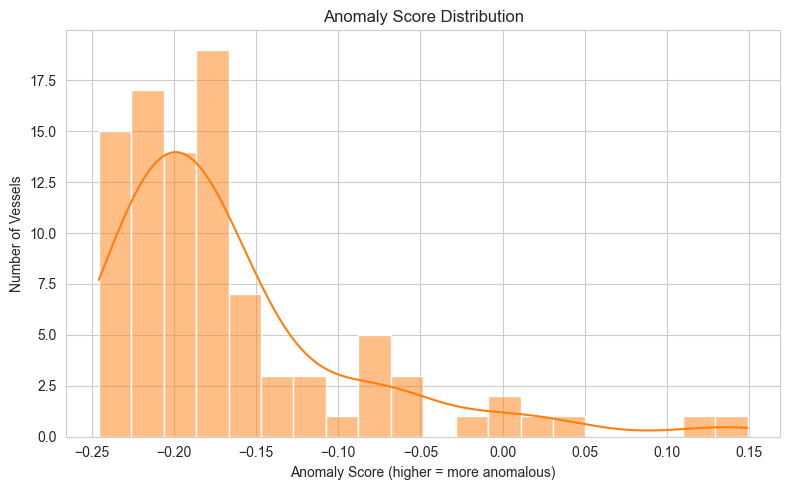

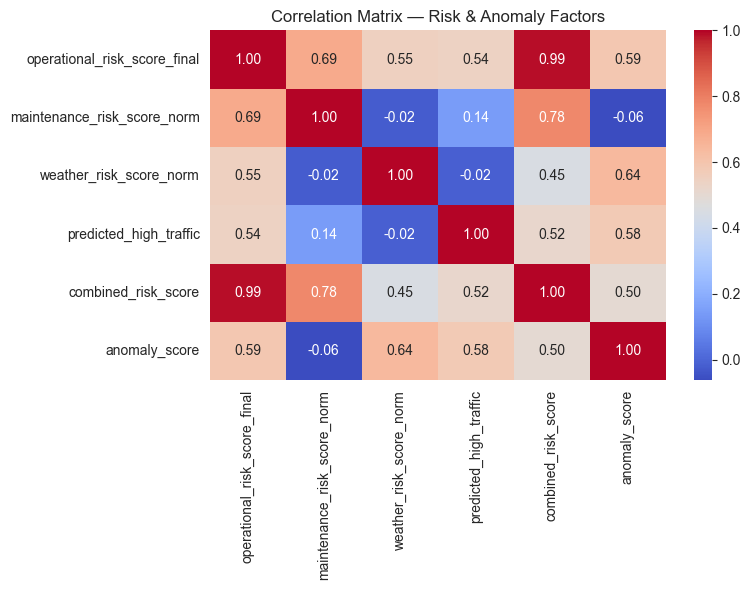

✅ Phase 5 Summary Dashboard generated and charts saved in docs/screens/phase5/


In [201]:
# ================================
# Summary Dashboard
# ================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# -------------------------------
# 1️⃣ Load the final Fleet Risk Intelligence dataset
# -------------------------------
df = pd.read_csv("../data/processed/AIS_Phase5_Final_Risk_Intelligence.csv")

# -------------------------------
# 2️⃣ Top 10 Critical Vessels (combined risk)
# -------------------------------
top_critical = df[df["combined_risk_alert"] == "Critical"].sort_values(
    "combined_risk_score", ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(9,6))
sns.barplot(
    data=top_critical,
    x="combined_risk_score",
    y="vessel_label",
    color="#d62728",  # Red
    ax=ax
)
ax.set_title("Top 10 Critical Vessels (Combined Risk)", fontsize=14)
ax.set_xlabel("Combined Risk Score")
ax.set_ylabel("Vessel")
plt.tight_layout()
fig.savefig("../docs/screens/phase5/dashboard_top10_critical.png", dpi=300)
plt.show()

# -------------------------------
# 3️⃣ Anomaly Score Distribution
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df["anomaly_score"], bins=20, kde=True, color="#ff7f0e")
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score (higher = more anomalous)")
plt.ylabel("Number of Vessels")
plt.tight_layout()
plt.savefig("../docs/screens/phase5/dashboard_anomaly_score_dist.png", dpi=300)
plt.show()

# -------------------------------
# 4️⃣ Correlation Heatmap between Risk Factors
# -------------------------------
corr_features = [
    "operational_risk_score_final",
    "maintenance_risk_score_norm",
    "weather_risk_score_norm",
    "predicted_high_traffic",
    "combined_risk_score",
    "anomaly_score"
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True
)
plt.title("Correlation Matrix — Risk & Anomaly Factors")
plt.tight_layout()
plt.savefig("../docs/screens/phase5/dashboard_risk_correlation.png", dpi=300)
plt.show()

# -------------------------------
# 5️⃣ Summary Completed
# -------------------------------
print("✅ Phase 5 Summary Dashboard generated and charts saved in docs/screens/phase5/")